Part 1
Slope: 0.9500000000000001, Intercept: 0.5900000000000001


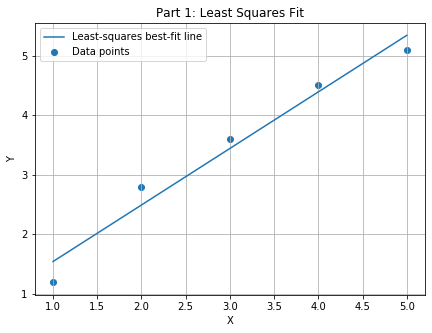


Part 2
Randomized X: [5. 2. 1. 4. 3.]
Randomized Y: [3.6 4.5 2.8 1.2 5.1]
Slope: -0.16999999999999915, Intercept: 3.9499999999999984


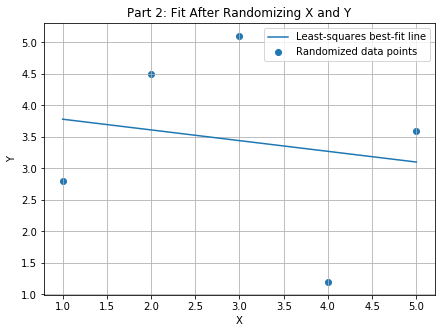


Part 2 note: If you randomize X and Y independently, you usually destroy the linear trend,
so the best-fit line often looks 'worse' / less meaningful than Part 1.

Part 3
True line:        y = 2.5x + -0.7
Least-squares fit: y = 2.5314x + -0.7104


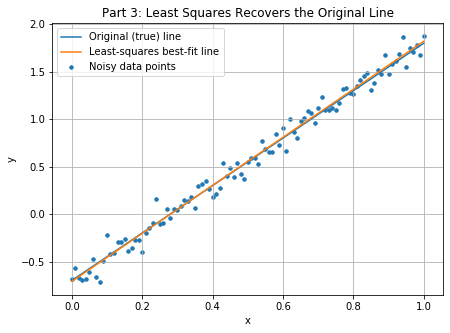

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1
X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

A = np.vstack([X, np.ones(len(X))]).T        
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]    

print("Part 1")
print(f"Slope: {m}, Intercept: {c}")

x_line = np.linspace(X.min(), X.max(), 200)
y_line = m * x_line + c

plt.figure(figsize=(7,5))
plt.scatter(X, Y, label="Data points")
plt.plot(x_line, y_line, label="Least-squares best-fit line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 1: Least Squares Fit")
plt.grid(True)
plt.legend()
plt.show()

# Part 2: Randomize the vectors and rerun

X_rand = np.random.permutation(X)
Y_rand = np.random.permutation(Y)

A_rand = np.vstack([X_rand, np.ones(len(X_rand))]).T
m2, c2 = np.linalg.lstsq(A_rand, Y_rand, rcond=None)[0]

print("\nPart 2")
print("Randomized X:", X_rand)
print("Randomized Y:", Y_rand)
print(f"Slope: {m2}, Intercept: {c2}")

x_line2 = np.linspace(X_rand.min(), X_rand.max(), 200)
y_line2 = m2 * x_line2 + c2

plt.figure(figsize=(7,5))
plt.scatter(X_rand, Y_rand, label="Randomized data points")
plt.plot(x_line2, y_line2, label="Least-squares best-fit line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 2: Fit After Randomizing X and Y")
plt.grid(True)
plt.legend()
plt.show()

print("\nPart 2 note: If you randomize X and Y independently, you usually destroy the linear trend,")
print("so the best-fit line often looks 'worse' / less meaningful than Part 1.")

# Part 3: Recover with least squares

m_true = 2.5
c_true = -0.7

x3 = np.arange(0.0, 1.0 + 0.01, 0.01) 
noise = np.random.normal(loc=0.0, scale=0.08, size=len(x3)) 
y3 = m_true * x3 + c_true + noise

A3 = np.vstack([x3, np.ones(len(x3))]).T
m3, c3 = np.linalg.lstsq(A3, y3, rcond=None)[0]

print("\nPart 3")
print(f"True line:        y = {m_true}x + {c_true}")
print(f"Least-squares fit: y = {m3:.4f}x + {c3:.4f}")

x_line3 = np.linspace(0, 1, 300)
y_true_line = m_true * x_line3 + c_true
y_fit_line  = m3 * x_line3 + c3

plt.figure(figsize=(7,5))
plt.scatter(x3, y3, s=12, label="Noisy data points")
plt.plot(x_line3, y_true_line, label="Original (true) line")
plt.plot(x_line3, y_fit_line, label="Least-squares best-fit line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Part 3: Least Squares Recovers the Original Line")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# I used ChatGPT mainly to double-check my Python syntax and make sure I was
# correctly building the design matrix and using np.linalg.lstsq for the
# least squares calculation. I also used it to confirm the plotting structure.
# The approach and interpretation of the results come from the lecture slides.
#
# AI Tool Used: ChatGPT
# Prompt Used:
# "Help verify my Python code for implementing least squares line fitting,
# plotting the data and best fit line, randomizing the vectors, and generating
# synthetic linear data with noise."